## Initialization

In [1]:
# NEVER EVER DELETE THIS CELL :-)


The goal of this project is to evaluate whether computer vision can be used to estimate a person’s age from facial images and determine if such a model can support real-world tasks such as age verification for alcohol purchases. Using a convolutional neural network based on a pretrained ResNet50 architecture, the model was trained to predict a person’s age from images. The key metric used to evaluate performance is Mean Absolute Error (MAE), which represents the average difference between predicted and actual age.

In [2]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam


## Load Data

The dataset is stored in the `/datasets/faces/` folder, there you can find
- The `final_files` folder with 7.6k photos
- The `labels.csv` file with labels, with two columns: `file_name` and `real_age`

Given the fact that the number of image files is rather high, it is advisable to avoid reading them all at once, which would greatly consume computational resources. We recommend you build a generator with the ImageDataGenerator generator. This method was explained in Chapter 3, Lesson 7 of this course.

The label file can be loaded as an usual CSV file.

In [3]:
labels_df = pd.read_csv('/datasets/faces/labels.csv')

# features_train = labels.drop('real_age', axis=1)
# target_train = labels['real_age']


Found 7591 validated image filenames.


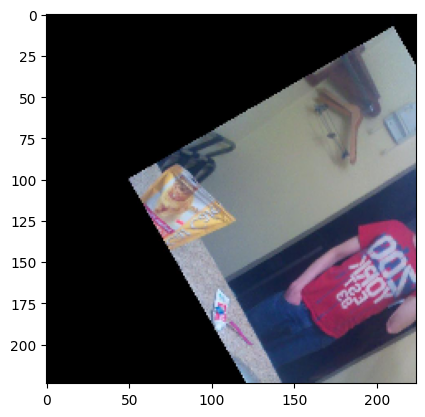

In [5]:

datagen = ImageDataGenerator(rescale=1./255)#<add the other argument here>)

generator = datagen.flow_from_dataframe(
dataframe=labels_df,
directory='/datasets/faces/final_files/',

x_col='file_name',
y_col='real_age',

target_size=(224, 224),
batch_size=32,
class_mode='raw' 
)



data, labels = next(generator)

plt.imshow(data[0])


In [6]:
print(f"Batch shape: {data.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Data type: {data.dtype}")
print(f"Labels (ages): {labels}")

Batch shape: (32, 224, 224, 3)
Labels shape: (32,)
Data type: float32
Labels (ages): [30 40 52  4 44 58 24 20 36 29 51 21 18 33 28  8 31 40 50  5 41 20 36  4
 34 51 22 30 18 25 65 50]


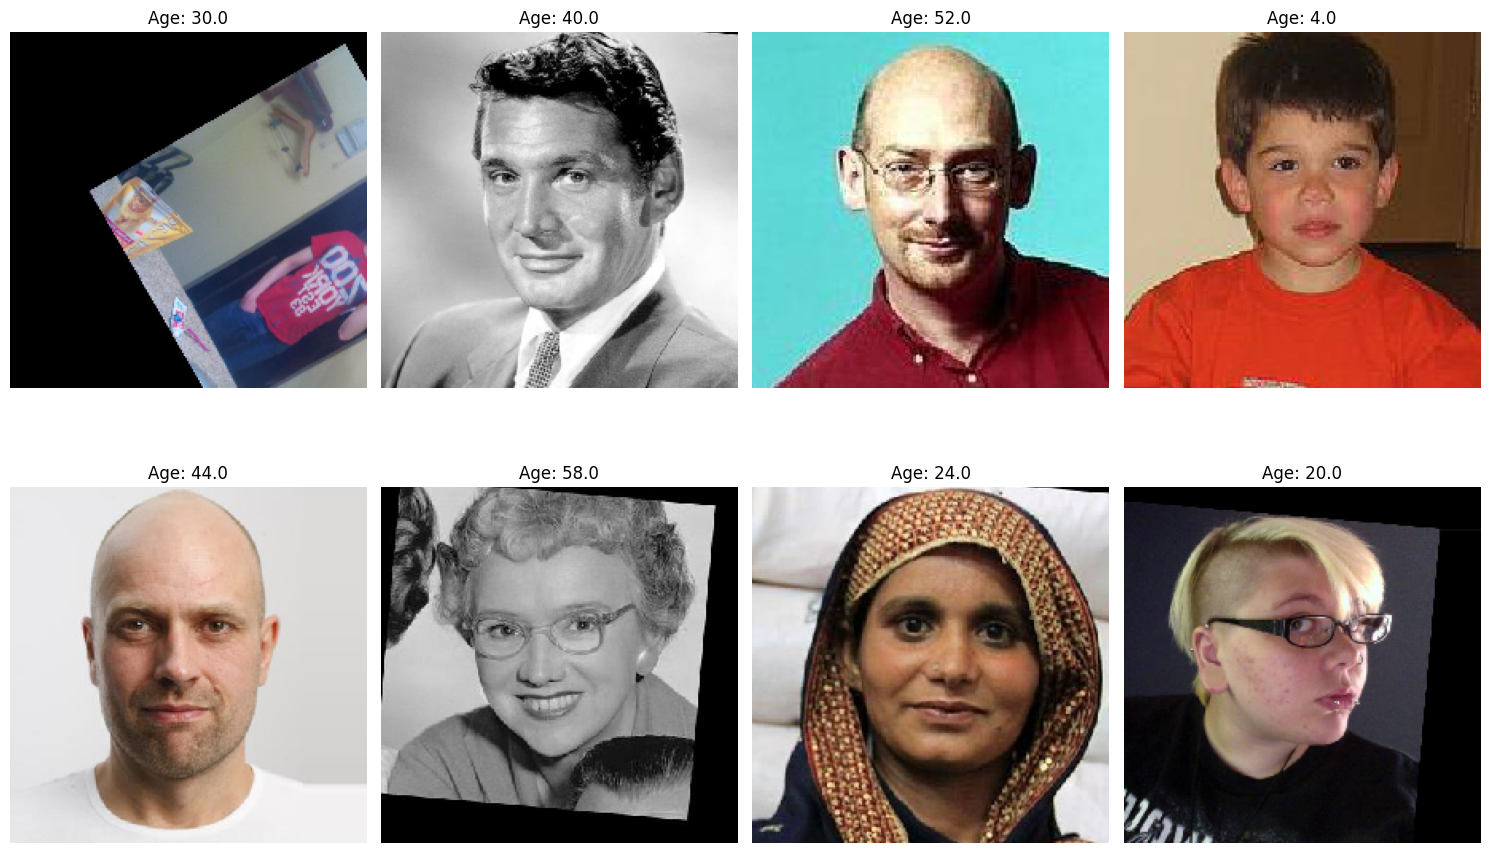

In [7]:
plt.figure(figsize=(15, 10))
for i in range(8):  # Show first 8 images
    plt.subplot(2, 4, i+1)
    plt.imshow(data[i])
    plt.title(f'Age: {labels[i]:.1f}')
    plt.axis('off')
plt.tight_layout()
plt.show()

## EDA

In [8]:
print(labels_df['real_age'].describe())
print(labels_df['real_age'].isnull().sum())
print(labels_df['real_age'].duplicated().sum())

count    7591.000000
mean       31.201159
std        17.145060
min         1.000000
25%        20.000000
50%        29.000000
75%        41.000000
max       100.000000
Name: real_age, dtype: float64
0
7494


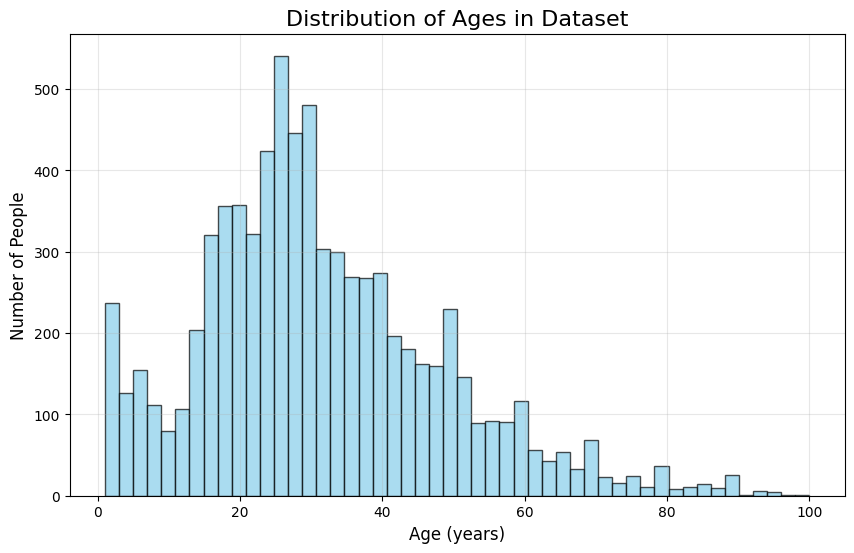

In [9]:
plt.figure(figsize=(10, 6))
labels_df['real_age'].hist(bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Ages in Dataset', fontsize=16)
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Number of People', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [10]:

print((labels_df['real_age'] <= 21).sum())
print(len(labels_df['real_age']))
print((labels_df['real_age'] <= 21).mean() * 100)

2197
7591
28.94216835726518


### Findings

The dataset contains 7,591 images with ages ranging from 1 to 100, showing a wide distribution of values. The mean age is approximately 31.2 and the median is 29, indicating that most individuals fall within the young adult range. The standard deviation of around 17 suggests high variability in ages. About 29% of individuals are aged 21 or younger, meaning younger people are well represented but do not dominate the dataset. The distribution is slightly right-skewed, with fewer samples in older age groups, particularly above 60. As a result, the dataset is moderately balanced but centered around ages 20–40, and this may lead the model to perform better on younger and middle-aged individuals while being less accurate for very young children and elderly individuals.

## Modelling

Define the necessary functions to train your model on the GPU platform and build a single script containing all of them along with the initialization section.

To make this task easier, you can define them in this notebook and run a ready code in the next section to automatically compose the script.

The definitions below will be checked by project reviewers as well, so that they can understand how you built the model.

In [11]:


def load_train(path):
    
    """
    It loads the train part of dataset from path
    """
    labels_df = pd.read_csv('/datasets/faces/labels.csv')
    datagen = ImageDataGenerator(validation_split=0.25, rescale=1./255)#<add the other argument here>)

    train_gen_flow = datagen.flow_from_dataframe(
        dataframe=labels_df,
        directory='/datasets/faces/final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=16,
        class_mode='raw',
        subset='training',
        seed=12345)


    



    return train_gen_flow


In [12]:
def load_test(path):

    """
    It loads the validation/test part of dataset from path
    """
    labels_df = pd.read_csv('/datasets/faces/labels.csv')
    datagen = ImageDataGenerator(validation_split=0.25, rescale=1./255)#<add the other argument here>)

    test_gen_flow = datagen.flow_from_dataframe(
        dataframe=labels_df,
        directory='/datasets/faces/final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=16,
        class_mode='raw',
        subset='validation',
        seed=12345)
    
    # place your code here

    return test_gen_flow

In [13]:

def create_model(input_shape):
    
    """
    It defines model
    """
    
    backbone = ResNet50(weights='imagenet', 
                        input_shape=input_shape,
                        include_top=False)

    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(1, activation='linear'))

    optimizer = Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

    return model


In [14]:


def train_model(model, train_data, test_data, batch_size=None, epochs=20,
                steps_per_epoch=None, validation_steps=None):

    """
    Trains the model given the parameters
    """
    
    if steps_per_epoch is None:
        steps_per_epoch = len(train_data)
        
    if validation_steps is None:
        validation_steps = len(test_data)

    model.fit(train_data, 
              validation_data=test_data,
              batch_size=batch_size, epochs=epochs,
              steps_per_epoch=steps_per_epoch,
              validation_steps=validation_steps,
              verbose=2)

    return model


### Prepare the Script to Run on the GPU Platform

Given you've defined the necessary functions you can compose a script for the GPU platform, download it via the "File|Open..." menu, and to upload it later for running on the GPU platform.

N.B.: The script should include the initialization section as well. An example of this is shown below.

In [15]:

# prepare a script to run on the GPU platform

init_str = """
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
"""

import inspect

with open('run_model_on_gpu.py', 'w') as f:
    
    f.write(init_str)
    f.write('\n\n')
        
    for fn_name in [load_train, load_test, create_model, train_model]:
        
        src = inspect.getsource(fn_name)
        f.write(src)
        f.write('\n\n')


### Output

Place the output from the GPU platform as an Markdown cell here.

Epoch 1/20
356/356 - 35s - loss: 95.3532 - mae: 7.4339 - val_loss: 124.3362 - val_mae: 8.4921
Epoch 2/20
356/356 - 35s - loss: 76.8372 - mae: 6.6707 - val_loss: 127.6357 - val_mae: 8.6035
Epoch 3/20
356/356 - 35s - loss: 69.9428 - mae: 6.3992 - val_loss: 91.1531 - val_mae: 7.4454
Epoch 4/20
356/356 - 35s - loss: 64.4249 - mae: 6.1407 - val_loss: 124.0287 - val_mae: 8.3481
Epoch 5/20
356/356 - 35s - loss: 52.8486 - mae: 5.5913 - val_loss: 109.1004 - val_mae: 8.2192
Epoch 6/20
356/356 - 35s - loss: 46.3094 - mae: 5.2223 - val_loss: 85.1038 - val_mae: 7.0332
Epoch 7/20
356/356 - 35s - loss: 38.2617 - mae: 4.7951 - val_loss: 92.0900 - val_mae: 7.3359
Epoch 8/20
356/356 - 35s - loss: 37.4804 - mae: 4.7402 - val_loss: 80.0016 - val_mae: 6.7239
Epoch 9/20
356/356 - 35s - loss: 33.5237 - mae: 4.4271 - val_loss: 83.2579 - val_mae: 6.8529
Epoch 10/20
356/356 - 35s - loss: 28.5170 - mae: 4.1411 - val_loss: 83.5056 - val_mae: 6.9629
Epoch 11/20
356/356 - 35s - loss: 27.0142 - mae: 3.9700 - val_loss: 92.1290 - val_mae: 7.1866
Epoch 12/20
356/356 - 35s - loss: 27.4564 - mae: 4.0428 - val_loss: 185.6307 - val_mae: 11.4591
Epoch 13/20
356/356 - 35s - loss: 23.7961 - mae: 3.7407 - val_loss: 92.3429 - val_mae: 7.2467
Epoch 14/20
356/356 - 35s - loss: 24.6167 - mae: 3.8116 - val_loss: 92.4542 - val_mae: 7.1401
Epoch 15/20
356/356 - 35s - loss: 22.2604 - mae: 3.6746 - val_loss: 82.5822 - val_mae: 6.7841
Epoch 16/20
356/356 - 35s - loss: 20.1899 - mae: 3.4430 - val_loss: 86.3830 - val_mae: 6.8304
Epoch 17/20
356/356 - 35s - loss: 17.3425 - mae: 3.2205 - val_loss: 78.4369 - val_mae: 6.6419
Epoch 18/20
356/356 - 35s - loss: 16.5249 - mae: 3.1295 - val_loss: 81.7731 - val_mae: 6.7226
Epoch 19/20
356/356 - 35s - loss: 16.6140 - mae: 3.1421 - val_loss: 80.9727 - val_mae: 6.9908
Epoch 20/20
356/356 - 35s - loss: 17.0187 - mae: 3.1785 - val_loss: 93.4115 - val_mae: 7.6512

## Conclusions

The model achieved a validation MAE of approximately 6.6–7 years, meaning that on average, predictions deviate from the true age by several years. While this demonstrates that computer vision can capture meaningful age-related features, the level of error is too high for reliable legal age verification. In the context of determining whether a person is 21 years old, an error of this magnitude could easily result in incorrect classifications, such as identifying a minor as an adult or vice versa.

Therefore, although the model is suitable for approximate age estimation and applications such as demographic analysis or marketing, it is not sufficiently accurate to be used as a standalone system for alcohol age verification. In practice, such a system could only be used as a supplementary tool alongside official identification checks, rather than replacing them.